# 
Microfinance Credit Risking for Rural Borrowers

This project develops a data-driven credit scoring system for rural farmers using their weekly revenue data.
The system analyzes historical income patterns, forecasts future earnings, and evaluates borrowers based on
financial stability and revenue strength.

Using these metrics, the model generates a credit score, estimates default probability, classifies borrowers
into risk categories, and recommends suitable loan amounts for microfinance institutions.

In [6]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
import pickle

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [8]:
file_path = "C:/Users/vasanth/datasets/Mock Data.csv"

farmers_df = pd.read_csv(
    file_path,
    index_col="Farmer No.",
    thousands=","
)

farmers_df.head()

,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,Week43,Week44,Week45,Week46,Week47,Week48,Week49,Week50,Week51,Week52
Farmer No.,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2918,1882,1939,1115
2,6487,10898,5133,3138,3056,5293,3170,2751,0,3333,...,900,0,1931,122,0,2704,7147,5125,2589,917
3,1289,1392,1789,1319,662,2290,1994,2527,1172,3059,...,2104,2306,1206,1417,1310,2153,1771,3527,3665,3110
4,3844,4256,3716,4511,5209,7299,9899,7440,1915,18215,...,23350,26493,1217,2791,0,5203,7938,1909,850,546
5,3428,2346,2419,2110,1569,2110,1951,936,169,235,...,548,1216,657,225,357,0,0,181,189,76


### Loading the Dataset

This cell reads the farmer revenue dataset from a CSV file and stores it in a Pandas DataFrame for further 
processing and analysis.

In [10]:
print("Shape:", farmers_df.shape)
farmers_df.describe()

Shape: (1275, 52)


,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,Week43,Week44,Week45,Week46,Week47,Week48,Week49,Week50,Week51,Week52
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,...,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,14984.454118,16007.744314,15136.750588,15412.348235,11932.422745,18038.498824,19770.973333,18944.767059,9279.968627,23176.995294,...,13906.559216,10880.016471,9369.428235,8956.124706,9583.287059,11130.280784,13879.662745,14266.894118,10084.778039,15305.047843
std,34427.387470,37055.987637,35325.119529,34375.358243,26475.195702,39944.456090,47577.790608,41383.825336,20859.309558,47749.294955,...,29253.523633,24283.426121,22619.675055,21577.699170,22787.558980,25713.935543,32825.291777,32147.934363,27421.623229,34553.161918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,340.000000,398.500000,447.500000,503.000000,156.000000,470.500000,381.000000,420.500000,0.000000,418.000000,...,622.500000,0.000000,0.000000,0.000000,0.000000,417.000000,1070.500000,1350.500000,645.500000,1433.500000
50%,4213.000000,4070.000000,4155.000000,4040.000000,3137.000000,4910.000000,4931.000000,4846.000000,2024.000000,6279.000000,...,4373.000000,3555.000000,2852.000000,2518.000000,2633.000000,3998.000000,5242.000000,5125.000000,2967.000000,5116.000000
75%,15508.500000,14976.500000,14060.500000,14902.500000,12083.500000,17435.500000,19164.000000,19121.500000,9982.500000,25384.500000,...,16810.500000,12837.500000,10571.500000,9219.000000,10104.500000,11903.500000,14753.500000,14591.500000,9503.500000,15432.000000
max,651762.000000,449877.000000,507413.000000,420506.000000,309626.000000,527924.000000,668722.000000,623627.000000,336218.000000,667226.000000,...,547147.000000,554049.000000,549871.000000,529063.000000,534634.000000,506125.000000,517352.000000,524823.000000,516755.000000,518525.000000


### Dataset Overview

This cell displays the basic structure and statistical summary of the dataset, including the number of rows, 
columns, and key descriptive statistics such as mean, minimum, and maximum revenue values.

In [11]:
file_path = "C:/Users/vasanth/datasets/Mock Data.csv"

farmers_df = pd.read_csv(
    file_path,
    index_col="Farmer No.",
    thousands=","
)

farmers_df.head()

,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,Week43,Week44,Week45,Week46,Week47,Week48,Week49,Week50,Week51,Week52
Farmer No.,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,2918,1882,1939,1115
2,6487,10898,5133,3138,3056,5293,3170,2751,0,3333,...,900,0,1931,122,0,2704,7147,5125,2589,917
3,1289,1392,1789,1319,662,2290,1994,2527,1172,3059,...,2104,2306,1206,1417,1310,2153,1771,3527,3665,3110
4,3844,4256,3716,4511,5209,7299,9899,7440,1915,18215,...,23350,26493,1217,2791,0,5203,7938,1909,850,546
5,3428,2346,2419,2110,1569,2110,1951,936,169,235,...,548,1216,657,225,357,0,0,181,189,76


### Data Cleaning and Filtering

This cell identifies farmers with missing or zero revenue weeks and filters the dataset to retain only 
reliable farmer records for further analysis.

In [12]:
print("Shape:", farmers_df.shape)
farmers_df.describe()

Shape: (1275, 52)


,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,Week43,Week44,Week45,Week46,Week47,Week48,Week49,Week50,Week51,Week52
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,...,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,14984.454118,16007.744314,15136.750588,15412.348235,11932.422745,18038.498824,19770.973333,18944.767059,9279.968627,23176.995294,...,13906.559216,10880.016471,9369.428235,8956.124706,9583.287059,11130.280784,13879.662745,14266.894118,10084.778039,15305.047843
std,34427.387470,37055.987637,35325.119529,34375.358243,26475.195702,39944.456090,47577.790608,41383.825336,20859.309558,47749.294955,...,29253.523633,24283.426121,22619.675055,21577.699170,22787.558980,25713.935543,32825.291777,32147.934363,27421.623229,34553.161918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,340.000000,398.500000,447.500000,503.000000,156.000000,470.500000,381.000000,420.500000,0.000000,418.000000,...,622.500000,0.000000,0.000000,0.000000,0.000000,417.000000,1070.500000,1350.500000,645.500000,1433.500000
50%,4213.000000,4070.000000,4155.000000,4040.000000,3137.000000,4910.000000,4931.000000,4846.000000,2024.000000,6279.000000,...,4373.000000,3555.000000,2852.000000,2518.000000,2633.000000,3998.000000,5242.000000,5125.000000,2967.000000,5116.000000
75%,15508.500000,14976.500000,14060.500000,14902.500000,12083.500000,17435.500000,19164.000000,19121.500000,9982.500000,25384.500000,...,16810.500000,12837.500000,10571.500000,9219.000000,10104.500000,11903.500000,14753.500000,14591.500000,9503.500000,15432.000000
max,651762.000000,449877.000000,507413.000000,420506.000000,309626.000000,527924.000000,668722.000000,623627.000000,336218.000000,667226.000000,...,547147.000000,554049.000000,549871.000000,529063.000000,534634.000000,506125.000000,517352.000000,524823.000000,516755.000000,518525.000000


In [13]:
farmers_df["Missing Weeks"] = farmers_df.apply(
    lambda s: (s == 0).sum(),
    axis=1
)

farmer_filtered_df = farmers_df[
    farmers_df["Missing Weeks"] < round(52 * 0.20)
].copy()

farmer_filtered_df.drop("Missing Weeks", axis=1, inplace=True)

print("Filtered farmers:", farmer_filtered_df.shape)

Filtered farmers: (824, 52)


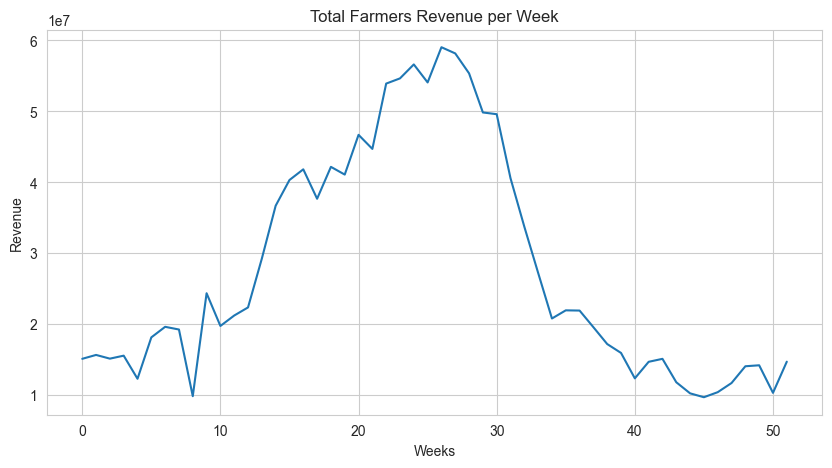

In [14]:
plt.figure(figsize=(10,5))

plt.plot(farmer_filtered_df.sum(axis=0).values)

plt.title("Total Farmers Revenue per Week")
plt.ylabel("Revenue")
plt.xlabel("Weeks")

plt.show()

### Weekly Revenue Trend Analysis

This cell visualizes the total revenue generated by all farmers across weeks. 
The graph helps identify income patterns, seasonal trends, and fluctuations in farmer earnings over time.

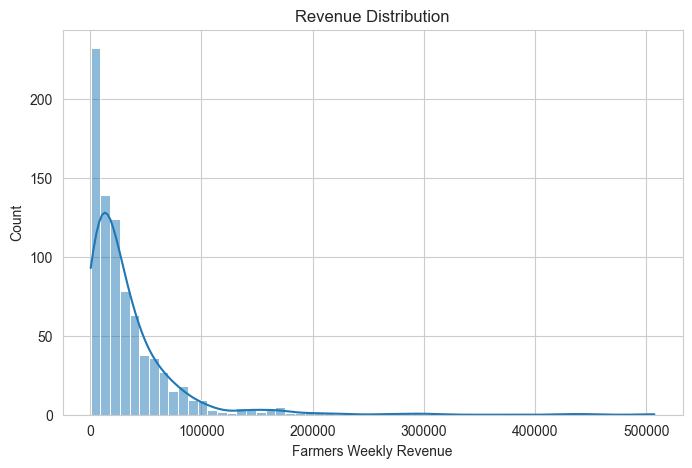

In [15]:
farmers_weekly_revenue = farmer_filtered_df.sum(axis=1) / 52

plt.figure(figsize=(8,5))

sns.histplot(farmers_weekly_revenue, kde=True)

plt.xlabel("Farmers Weekly Revenue")
plt.title("Revenue Distribution")

plt.show()

### Revenue Distribution Analysis

This cell plots the distribution of farmers’ average weekly revenue to understand how income is spread 
across the farmer population.

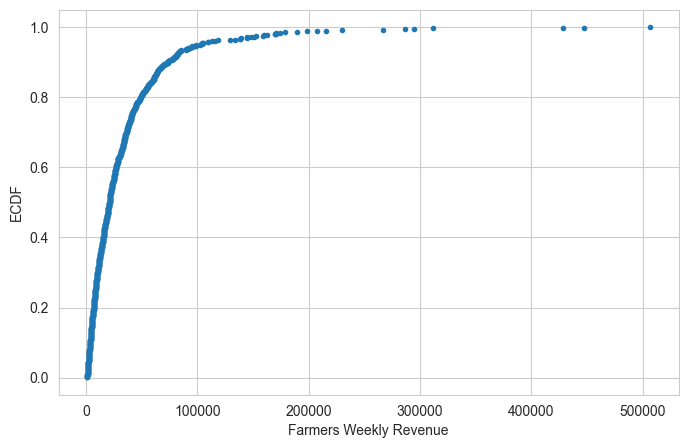

In [16]:
def ecdf(data):
    
    n = len(data)
    x = np.sort(data)
    y = np.arange(1, n+1) / n
    
    return x, y


farm_x, farm_y = ecdf(farmers_weekly_revenue)

plt.figure(figsize=(8,5))

plt.plot(farm_x, farm_y, marker=".", linestyle="none")

plt.xlabel("Farmers Weekly Revenue")
plt.ylabel("ECDF")

plt.show()

### Empirical Cumulative Distribution Function (ECDF)

This cell calculates and visualizes the cumulative distribution of farmer revenues, helping understand 
the proportion of farmers earning below or above certain revenue levels.

In [17]:
dates = []

for week in range(1, 53):

    week_str = "2017-W" + str(week)
    
    date = datetime.datetime.strptime(
        week_str + "-0", "%Y-W%W-%w"
    ).date()

    dates.append(date)

dates[:5]

[datetime.date(2017, 1, 8),
 datetime.date(2017, 1, 15),
 datetime.date(2017, 1, 22),
 datetime.date(2017, 1, 29),
 datetime.date(2017, 2, 5)]

### Time Series Preparation

This cell converts weekly revenue data into a time-series format so that forecasting models can analyze 
revenue patterns over time.

In [18]:
def evaluate_arima_model(train_X, test_X, order):

    history = np.log(np.array(train_X) + 1).tolist()
    test = np.log(np.array(test_X) + 1).tolist()

    predictions = []

    for t in range(len(test)):

        model = ARIMA(history, order=order)
        model_fit = model.fit()

        yhat = model_fit.forecast()[0]

        predictions.append(yhat)
        history.append(test[t])

    error = mean_squared_error(test, predictions)

    return error

### ARIMA Model Evaluation

This cell evaluates different ARIMA model configurations to determine the best parameters for forecasting 
future farmer revenues.

In [19]:
def evaluate_models(train, test, p_values, d_values, q_values):

    best_score = float("inf")
    best_cfg = None

    for p in p_values:
        for d in d_values:
            for q in q_values:

                order = (p,d,q)

                try:

                    mse = evaluate_arima_model(train, test, order)

                    if mse < best_score:

                        best_score = mse
                        best_cfg = order

                    print("ARIMA%s MSE=%.3f" % (order, mse))

                except:
                    continue

    print("Best ARIMA%s MSE=%.3f" % (best_cfg, best_score))

    return best_cfg

### ARIMA Parameter Optimization

This cell searches across multiple ARIMA parameter combinations to identify the model that produces the 
lowest forecasting error.

In [20]:
p_values = [0,1,2]
d_values = range(0,2)
q_values = range(0,3)

orders = {}

train_size = int(0.75 * 52)

i = 0

for index, row in farmer_filtered_df.head(10).iterrows():

    train_series = row[:train_size]
    test_series = row[train_size:]

    i += 1
    print("Farmer:", i)

    best_order = evaluate_models(
        train_series,
        test_series,
        p_values,
        d_values,
        q_values
    )

    orders[str(index)] = best_order

orders

Farmer: 1
ARIMA(0, 0, 0) MSE=16.592
ARIMA(0, 0, 1) MSE=15.826
ARIMA(0, 0, 2) MSE=17.901
ARIMA(0, 1, 0) MSE=25.720
ARIMA(0, 1, 1) MSE=14.087
ARIMA(0, 1, 2) MSE=14.984
ARIMA(1, 0, 0) MSE=15.925
ARIMA(1, 0, 1) MSE=15.128
ARIMA(1, 0, 2) MSE=14.679
ARIMA(1, 1, 0) MSE=20.838
ARIMA(1, 1, 1) MSE=14.780
ARIMA(1, 1, 2) MSE=15.642
ARIMA(2, 0, 0) MSE=15.938
ARIMA(2, 0, 1) MSE=15.554
ARIMA(2, 0, 2) MSE=13.959
ARIMA(2, 1, 0) MSE=15.126
ARIMA(2, 1, 1) MSE=15.337
ARIMA(2, 1, 2) MSE=16.705
Best ARIMA(2, 0, 2) MSE=13.959
Farmer: 2
ARIMA(0, 0, 0) MSE=8.406
ARIMA(0, 0, 1) MSE=5.183
ARIMA(0, 0, 2) MSE=3.932
ARIMA(0, 1, 0) MSE=3.136
ARIMA(0, 1, 1) MSE=4.549
ARIMA(0, 1, 2) MSE=6.041
ARIMA(1, 0, 0) MSE=2.723
ARIMA(1, 0, 1) MSE=3.517
ARIMA(1, 0, 2) MSE=4.447
ARIMA(1, 1, 0) MSE=5.376
ARIMA(1, 1, 1) MSE=5.060
ARIMA(1, 1, 2) MSE=4.652
ARIMA(2, 0, 0) MSE=4.460
ARIMA(2, 0, 1) MSE=3.967
ARIMA(2, 0, 2) MSE=2.673
ARIMA(2, 1, 0) MSE=5.005
ARIMA(2, 1, 1) MSE=5.442
ARIMA(2, 1, 2) MSE=5.738
Best ARIMA(2, 0, 2) MSE=2.673
F

{'2': (2, 0, 2),
 '3': (2, 0, 2),
 '4': (1, 0, 1),
 '5': (0, 0, 2),
 '11': (0, 0, 1),
 '13': (1, 0, 0),
 '15': (1, 0, 1),
 '16': (0, 0, 2),
 '18': (1, 0, 0),
 '19': (1, 0, 2)}

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

def forecast_next_13_weeks(data, order):

    model = ARIMA(data, order=order)
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=13)

    return forecast

### Revenue Forecasting

This cell uses the selected ARIMA model to forecast future weekly revenues for farmers based on historical 
income data.

In [22]:
# create dataframe with predefined 13 forecast columns
forecast_columns = ["forecast_week_" + str(i) for i in range(1,14)]

forecasted_revenues = pd.DataFrame(columns=forecast_columns)

for index, row in farmer_filtered_df.head(100).iterrows():

    order = orders.get(str(index), (1,1,1))

    farmer_row = np.log(np.array(row) + 1)

    preds = np.exp(forecast_next_13_weeks(farmer_row, order))

    # ensure length = 13
    preds = list(preds)[:13]

    forecasted_revenues.loc[index] = preds

forecasted_revenues.head()

,forecast_week_1,forecast_week_2,forecast_week_3,forecast_week_4,forecast_week_5,forecast_week_6,forecast_week_7,forecast_week_8,forecast_week_9,forecast_week_10,forecast_week_11,forecast_week_12,forecast_week_13
2,1433.606557,1573.705639,1553.796979,1666.492052,1652.237141,1741.463033,1731.529349,1801.325462,1794.591247,1848.689339,1844.261557,1885.901059,1883.096582
3,2281.553003,1674.823410,1513.497995,1341.649678,1277.819238,1217.971200,1190.997132,1168.104047,1156.468768,1147.306900,1142.271841,1138.518966,1136.345576
4,1236.386611,1389.062349,1549.456483,1716.795125,1890.246704,2068.939949,2251.981131,2438.470139,2627.515039,2818.244918,3009.820878,3201.445141,3392.368295
5,156.569664,325.447074,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379
11,12739.254193,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386


### Storing Forecasted Revenues

This cell creates new columns to store predicted revenue values for the upcoming weeks.

In [23]:
forecasted_revenues.shape

(100, 13)

In [24]:
final_farmers_df = pd.merge(
    farmer_filtered_df,
    forecasted_revenues,
    left_index=True,
    right_index=True,
    how="inner"
)

final_farmers_df.head()

,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,forecast_week_4,forecast_week_5,forecast_week_6,forecast_week_7,forecast_week_8,forecast_week_9,forecast_week_10,forecast_week_11,forecast_week_12,forecast_week_13
2,6487,10898,5133,3138,3056,5293,3170,2751,0,3333,...,1666.492052,1652.237141,1741.463033,1731.529349,1801.325462,1794.591247,1848.689339,1844.261557,1885.901059,1883.096582
3,1289,1392,1789,1319,662,2290,1994,2527,1172,3059,...,1341.649678,1277.819238,1217.971200,1190.997132,1168.104047,1156.468768,1147.306900,1142.271841,1138.518966,1136.345576
4,3844,4256,3716,4511,5209,7299,9899,7440,1915,18215,...,1716.795125,1890.246704,2068.939949,2251.981131,2438.470139,2627.515039,2818.244918,3009.820878,3201.445141,3392.368295
5,3428,2346,2419,2110,1569,2110,1951,936,169,235,...,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379
11,0,2407,934,1639,8641,15669,13667,12997,5931,12871,...,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386


In [25]:
final_farmers_df = pd.merge(
    farmer_filtered_df,
    forecasted_revenues,
    left_index=True,
    right_index=True,
    how="inner"
)

final_farmers_df.head(100)

,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,forecast_week_4,forecast_week_5,forecast_week_6,forecast_week_7,forecast_week_8,forecast_week_9,forecast_week_10,forecast_week_11,forecast_week_12,forecast_week_13
2,6487,10898,5133,3138,3056,5293,3170,2751,0,3333,...,1666.492052,1652.237141,1741.463033,1731.529349,1801.325462,1794.591247,1848.689339,1844.261557,1885.901059,1883.096582
3,1289,1392,1789,1319,662,2290,1994,2527,1172,3059,...,1341.649678,1277.819238,1217.971200,1190.997132,1168.104047,1156.468768,1147.306900,1142.271841,1138.518966,1136.345576
4,3844,4256,3716,4511,5209,7299,9899,7440,1915,18215,...,1716.795125,1890.246704,2068.939949,2251.981131,2438.470139,2627.515039,2818.244918,3009.820878,3201.445141,3392.368295
5,3428,2346,2419,2110,1569,2110,1951,936,169,235,...,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379,323.997379
11,0,2407,934,1639,8641,15669,13667,12997,5931,12871,...,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386,7291.801386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,1452,1407,1195,1438,905,0,0,0,0,4497,...,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977,16418.882977
168,4547,4316,4800,5409,6981,7697,9518,11021,7070,18801,...,13882.616999,13882.403371,13882.370979,13882.366068,13882.365323,13882.365210,13882.365193,13882.365190,13882.365190,13882.365190
169,0,0,0,6787,9795,15182,16866,17130,10353,23734,...,20550.555271,20710.202816,20856.808773,20991.350464,21114.747059,21227.860287,21331.495759,21426.404739,21513.286251,21592.789422
173,20389,16922,9707,11416,11096,21849,24152,25414,14038,33671,...,11441.666136,11438.857679,11438.364905,11438.278433,11438.263258,11438.260595,11438.260128,11438.260046,11438.260032,11438.260029


### Combining Historical and Forecast Data

This cell merges the original revenue data with the forecasted values to create a unified dataset for 
credit evaluation.

In [26]:
final_farmers_df["Mean Forecasted Revenue"] = forecasted_revenues.mean(axis=1)

ninty_percentile = np.percentile(
    final_farmers_df["Mean Forecasted Revenue"], 90
)

final_farmers_df["Value Score"] = (
    final_farmers_df["Mean Forecasted Revenue"] > ninty_percentile
).astype(int)

### Value Score Calculation

This cell calculates a Value Score based on the average predicted revenue of each farmer, representing 
their income strength and repayment capacity.

In [27]:
min_rev = final_farmers_df["Mean Forecasted Revenue"].min()
max_rev = final_farmers_df["Mean Forecasted Revenue"].max()

final_farmers_df["Value Score"] = (
    final_farmers_df["Mean Forecasted Revenue"] - min_rev
) / (max_rev - min_rev)

In [28]:
timeseries = np.arange(13)

final_farmers_df["Stability Trend Score"] = [

    np.corrcoef(x, timeseries)[0][1] * 0.3

    for x in forecasted_revenues.values
]

### Stability Trend Score

This cell evaluates the consistency of a farmer’s income over time by analyzing revenue trends. 
More stable income results in a higher stability score.

In [29]:
final_farmers_df["Farmer Rating"] = (
    final_farmers_df["Stability Trend Score"]
    + final_farmers_df["Value Score"]
)

final_farmers_df["Eligibility"] = (
    final_farmers_df["Farmer Rating"] >= 0.5
)

### Farmer Rating Calculation

This cell combines the Value Score and Stability Trend Score to generate an overall rating that reflects 
a farmer's financial reliability.

In [30]:
# Normalize Farmer Rating into a credit score (300 - 850 scale)

min_rating = final_farmers_df["Farmer Rating"].min()
max_rating = final_farmers_df["Farmer Rating"].max()

final_farmers_df["Credit Score"] = 300 + (
    (final_farmers_df["Farmer Rating"] - min_rating) /
    (max_rating - min_rating)
) * (850 - 300)

### Credit Score Generation

This cell converts farmer ratings into standardized credit scores similar to traditional financial 
credit scoring systems.

In [31]:
import numpy as np

final_farmers_df["Default Probability"] = 1 / (
    1 + np.exp((final_farmers_df["Credit Score"] - 600)/50)
)

### Default Probability Estimation

This cell estimates the likelihood that a farmer might default on a loan based on their credit score 
and financial indicators.

In [32]:
def classify_risk(score):

    if score >= 700:
        return "Low Risk"

    elif score >= 550:
        return "Medium Risk"

    else:
        return "High Risk"

### Risk Classification

This cell categorizes farmers into Low Risk, Medium Risk, or High Risk groups based on their credit score 
and predicted repayment ability.

In [35]:
print(final_farmers_df.columns)

Index(['Week1', 'Week2', 'Week3', 'Week4', 'Week5', 'Week6', 'Week7', 'Week8',
       'Week9', 'Week10', 'Week11', 'Week12', 'Week13', 'Week14', 'Week15',
       'Week16', 'Week17', 'Week18', 'Week19', 'Week20', 'Week21', 'Week22',
       'Week23', 'Week24', 'Week25', 'Week26', 'Week27', 'Week28', 'Week29',
       'Week30', 'Week31', 'Week32', 'Week33', 'Week34', 'Week35', 'Week36',
       'Week37', 'Week38', 'Week39', 'Week40', 'Week41', 'Week42', 'Week43',
       'Week44', 'Week45', 'Week46', 'Week47', 'Week48', 'Week49', 'Week50',
       'Week51', 'Week52', 'forecast_week_1', 'forecast_week_2',
       'forecast_week_3', 'forecast_week_4', 'forecast_week_5',
       'forecast_week_6', 'forecast_week_7', 'forecast_week_8',
       'forecast_week_9', 'forecast_week_10', 'forecast_week_11',
       'forecast_week_12', 'forecast_week_13', 'Mean Forecasted Revenue',
       'Value Score', 'Stability Trend Score', 'Farmer Rating', 'Eligibility',
       'Credit Score', 'Default Probability'],
 

In [36]:
def classify_risk(score):
    
    if score >= 750:
        return "Low Risk"
    
    elif score >= 650:
        return "Medium Risk"
    
    else:
        return "High Risk"


final_farmers_df["Risk Category"] = final_farmers_df["Credit Score"].apply(classify_risk)

In [37]:
def calculate_loan_amt(revenue, risk):

    if risk == "Low Risk":
        return revenue * 0.30 * 13
    
    elif risk == "Medium Risk":
        return revenue * 0.20 * 13
    
    else:
        return revenue * 0.10 * 13


final_farmers_df["Recommended Loan Amount"] = final_farmers_df.apply(
    lambda row: calculate_loan_amt(
        row["Mean Forecasted Revenue"],
        row["Risk Category"]
    ),
    axis=1
)

### Loan Amount Recommendation

This cell calculates the recommended loan amount for each farmer based on their revenue potential and 
risk category.

In [38]:
final_farmers_df["Recommended Loan Amount"] = final_farmers_df["Recommended Loan Amount"].clip(upper=100000)

In [40]:
def calculate_loan_amt(revenue):

    if revenue >= np.percentile(final_farmers_df["Mean Forecasted Revenue"], 90):
        return round(revenue * 0.35 * 13)

    elif revenue >= np.percentile(final_farmers_df["Mean Forecasted Revenue"], 50):
        return round(revenue * 0.30 * 13)

    else:
        return round(revenue * 0.20 * 13)


loans = []

for index, row in final_farmers_df.iterrows():

    if row["Eligibility"]:

        loans.append(calculate_loan_amt(row["Mean Forecasted Revenue"]))

    else:

        loans.append(0)

final_farmers_df["Loan Amt."] = loans

### Loan Approval Decision

This cell determines whether a loan should be approved or rejected based on the farmer's risk category.

In [41]:
final_farmers_df.to_csv("Results.csv")

print("Results saved successfully.")

Results saved successfully.


### Saving Final Results

This cell saves the final dataset containing credit scores, risk classifications, and loan recommendations 
into a CSV file for further analysis or reporting.

In [42]:
final_farmers_df["Loan Approval"] = final_farmers_df["Risk Category"].apply(
    lambda x: "Approved" if x != "High Risk" else "Rejected"
)

final_farmers_df.head()

,Week1,Week2,Week3,Week4,Week5,Week6,Week7,Week8,Week9,Week10,...,Value Score,Stability Trend Score,Farmer Rating,Eligibility,Credit Score,Default Probability,Risk Category,Recommended Loan Amount,Loan Amt.,Loan Approval
2,6487,10898,5133,3138,3056,5293,3170,2751,0,3333,...,0.006803,0.288152,0.294955,False,573.217017,0.630802,High Risk,2241.069599,0,Rejected
3,1289,1392,1789,1319,662,2290,1994,2527,1172,3059,...,0.005277,-0.233147,-0.227870,False,331.138031,0.995401,High Risk,1738.732775,0,Rejected
4,3844,4256,3716,4511,5209,7299,9899,7440,1915,18215,...,0.008984,0.299838,0.308822,False,579.637857,0.600427,High Risk,2959.073276,0,Rejected
5,3428,2346,2419,2110,1569,2110,1951,936,169,235,...,0.001225,0.137766,0.138992,False,501.002701,0.878675,High Risk,404.598791,0,Rejected
11,0,2407,934,1639,8641,15669,13667,12997,5931,12871,...,0.030442,-0.138873,-0.108431,False,386.440677,0.986227,High Risk,10024.087082,0,Rejected


In [43]:
!pip install streamlit